## This python file can transfor graphene cell from HEX to rectangle

In [1]:
from ase.build import graphene, sort
from ase.visualize import view

### part 1 genereat graphenen primitive cell

In [2]:
# primitive HEX2D
atoms = graphene(a=2.59615, size=(1, 1, 1)) # lattice parameter
# view(atoms)

### part 2 cell transfor from HEX2D to rectangle
参考OneNote笔记-动力学前后处理-建模-六角冰的lammps建模及其构型优化

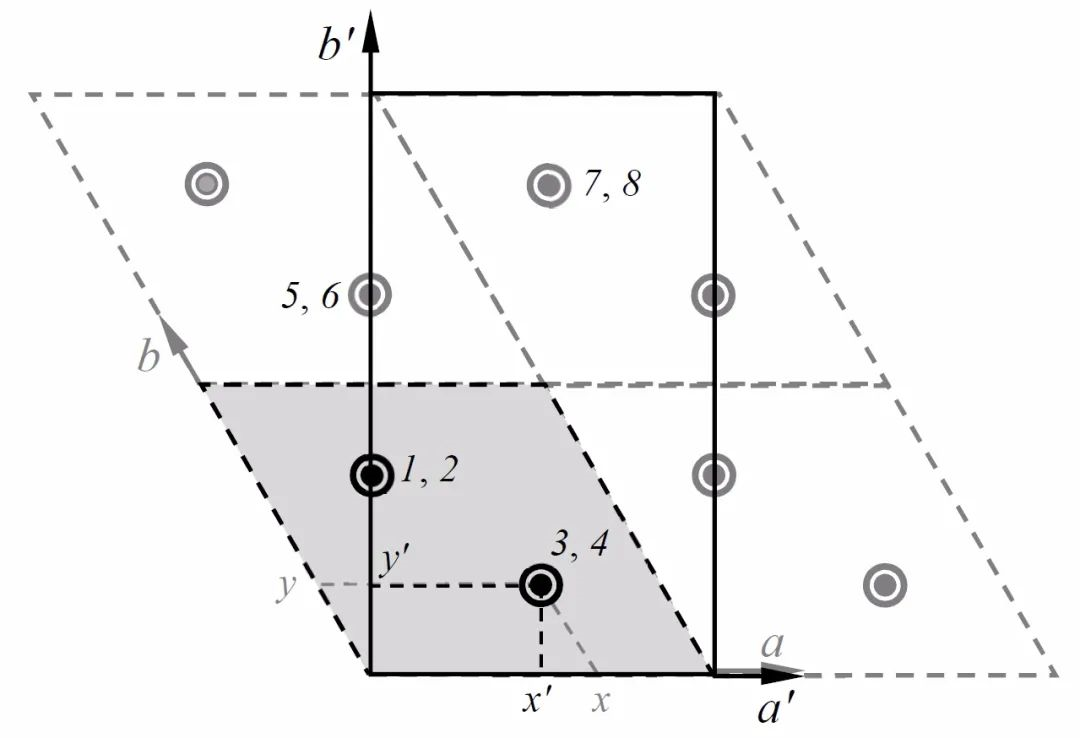

In [3]:
# primitive HEX2D to minimize repeat cell
# for HEX2D,  a==b!=c; alpha==beta==90, gamma==120 -> a!=b!=c; alpha==beta==gamma==90
atoms = atoms.repeat((2, 2, 1))    #same as atoms = atoms*(2,2,1)  cell will be super automatically 
# view(atoms)

In [4]:
# get cell before 
cell_before = atoms.get_cell()
# print('cell-before=',cell_before)         #ase当中, cell的设置可以在cell()中必须是列表[]，可以是三个晶格矢量的二维列表形式，也可以是六个晶格常数的一维列表形式
                                            # see ASE document: https://wiki.fysik.dtu.dk/ase/_modules/ase/atoms.html#Atoms.set_cell
# HEX2D to RECT(rectangle)                  #set transformation matrix
transfor_matrix = ((0.5, 0.0, 0.0),         #for a, we want 0.5 times       
                   (0.0, 1.0, 0.0),         #for b, we don't want components in the x-direction, and want components in the y-direction don't change(1 times)
                   (0.0, 0.0, 1.0))         #for c, nothing want
matrix_cell = transfor_matrix*cell_before   #cell_before是ase调用numpy生成的矩阵, 当二维元组transfor_matrix与之相乘(*)，numpy自动将其转化为矩阵。
# print(cell_after_matrix)                  #so, write transfor_matrix in the form of list is OK

atoms.set_cell(matrix_cell)                 #cell transformation

# get cell after
cell_after=atoms.get_cell()                 #BTW, while cell is Tetragonal(四方) or Cubic(立方), Cell() will only show Cell([a, a, c])    (简化显示)
# print('cell-after=',cell_after)           #but actually Cell() is still Cell([[a,0,0], [0,a,0], [0,0,c]])   (内部存储没有简化)

# view(atoms)

### part 3 delete atoms out of periodic image

In [5]:
# Delet atoms of repeat and out of unit cell, also called warp
scaled_positions = atoms.get_scaled_positions(wrap=False)      #获取atoms的分数坐标, 当warp=True，原子被自动wrap，分数坐标将被限制在0-1.
# print(scaled_positions)                                      #at the same time, 分数坐标方便下面使用eps比较大小，否则直角坐标需要每次修改eps大小

eps = 1e-03
bool_oper =  (scaled_positions > -eps) & (scaled_positions < 1-eps)  #bool_operation to judge which atoms is out of unit cell.
# print(bool_oper)                                                     #here, coordinate of atoms in each direction will be judge separately
bool_oper_2 = bool_oper.all(axis=1) #对bool数组进行判断，沿着高维数组的第一个轴(即每一行)判断所有元素是否都为True，如是，返回True，否则，False
# print(bool_oper_2)

atoms = atoms[bool_oper_2]          #delect atoms out of unit cell and  repeat atoms at boundary
view(atoms)                         #对原子的操作，使用atoms[]


<Popen: returncode: None args: ['e:\\Project\\pywork\\ASE\\Scripts\\python.e...>

#### part 4 replace specify atoms element

In [6]:
# super cell of graphene
atoms = atoms.repeat((5, 3, 1))     #super to 5*5 benzene ring, and the sell will be super automatically
# view(atoms)

# change element of N
atoms.symbols[[28, 30, 40, 42]] = 'N'
# you could also use get_chemical_symbols() and set_chemical_symbols() to achive this

# change element of Fe

pos1 = atoms.positions[29]
pos2 = atoms.positions[31]
# print('pos of atoms_29 is {}, \npos of atoms_31 is {}' .format(pos1, pos2))
Fe_pos = [(pos1 + pos2)/2]      #ase need positions is a 2D list, so there is []
# print('pos of atoms_Fe will be {}' .format(Fe_pos))

from ase import Atoms
Fe = Atoms(symbols="Fe", positions=Fe_pos)
atoms.extend(Fe)    #append Fe to atoms

# del C atoms
del atoms[[31, 29]] 

view(atoms)


<Popen: returncode: None args: ['e:\\Project\\pywork\\ASE\\Scripts\\python.e...>

#### part 5 move to middom and generate vacuum

In [7]:
# generate vacuum

# atoms.cell[2][2] += 15      #the index must be 2D([2,2]or[2][2]), otherwise the value of c of cell will be [15,15,15] (i.e. a three diagonal direction)
# atoms.center(axis=2)
atoms.center(vacuum=7.5, axis=2)    #add vacuum in the direction of z(axis=2), vacuum will be added to both sides of center. Here, axis means index of direction.

view(atoms)


<Popen: returncode: None args: ['e:\\Project\\pywork\\ASE\\Scripts\\python.e...>

#### part 6 generate out put file

In [50]:
atoms.set_pbc((True, True, True))

# according to chemical symbols,  sorted atomic order. sort is imported from ase.build
atoms = sort(atoms)

from ase.io import write
write('graphene.poscar', atoms, format='vasp')

In [8]:
atoms.set_pbc((True, True, True))
atoms = atoms.repeat((3, 3, 1)) 
# according to chemical symbols,  sorted atomic order. sort is imported from ase.build
atoms = sort(atoms)

from ase.io import write
write('graphene.pdb', atoms)